# CIFAR-10_comparison_runs

Setup, train, and visualize metrics.


In [1]:
# Start clean
%cd /
!rm -rf /content/mixture-of-experts-project
%cd /content

# Clone the repo and switch to your branch
!git clone https://github.com/moe-project-uu/mixture-of-experts-project.git
%cd mixture-of-experts-project
!git checkout -f arokah
!git branch   # confirm you're on 'arokah'

# Install dependencies into THIS Colab Python (important!)
import sys
!{sys.executable} -m pip install -U pip setuptools wheel
!{sys.executable} -m pip install -r requirements.txt
!{sys.executable} -m pip install -e .

# Quick check that it worked
import moe
print("Imported moe from:", moe.__file__)


/
/content
Cloning into 'mixture-of-experts-project'...
remote: Enumerating objects: 1115, done.
remote: Counting objects: 100% (263/263), done.
remote: Compressing objects: 100% (180/180), done.
remote: Total 1115 (delta 122), reused 185 (delta 75), pack-reused 852 (from 1)
Receiving objects: 100% (1115/1115), 94.84 MiB | 17.33 MiB/s, done.
Resolving deltas: 100% (441/441), done.
/content/mixture-of-experts-project
Branch 'arokah' set up to track remote branch 'arokah' from 'origin'.
Switched to a new branch 'arokah'
* arokah
  main
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.5/828.5 kB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.4/832.4 kB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 77.9 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1

In [2]:
# Train via CLI so argparse is used
%cd /content/mixture-of-experts-project

!python scripts/train_cifar10.py --FF_layer SparseMoE --epochs 50 --num_experts 16 --dropout_p 0.1 --temperature 1 --sparsemoe_importance_coef 0.2 --sparsemoe_load_coef 0.2


/content/mixture-of-experts-project
100% 170M/170M [00:13<00:00, 12.5MB/s]
dataloaders metadata: {'mean': (0.4914, 0.4822, 0.4465), 'std': (0.247, 0.2435, 0.2616), 'num_classes': 10, 'sizes': {'train': 45000, 'val': 5000, 'test': 10000}}
Epoch 1/50: 100% 352/352 [00:17<00:00, 20.66it/s]
Epoch 001/50 | train_loss=1.9290 train_acc=32.54% | val_loss=1.5123 val_acc=44.48%
Saved checkpoint: SparseMoE val_acc=44.48%
Epoch 2/50: 100% 352/352 [00:14<00:00, 23.65it/s]
Epoch 002/50 | train_loss=1.3273 train_acc=55.93% | val_loss=1.2316 val_acc=57.06%
Saved checkpoint: SparseMoE val_acc=57.06%
Epoch 3/50: 100% 352/352 [00:14<00:00, 24.18it/s]
Epoch 003/50 | train_loss=0.9877 train_acc=68.75% | val_loss=1.1576 val_acc=62.46%
Saved checkpoint: SparseMoE val_acc=62.46%
Epoch 4/50: 100% 352/352 [00:14<00:00, 24.31it/s]
Epoch 004/50 | train_loss=0.7977 train_acc=75.75% | val_loss=1.0751 val_acc=66.08%
Saved checkpoint: SparseMoE val_acc=66.08%
Epoch 5/50: 100% 352/352 [00:14<00:00, 23.76it/s]
Epoch 00

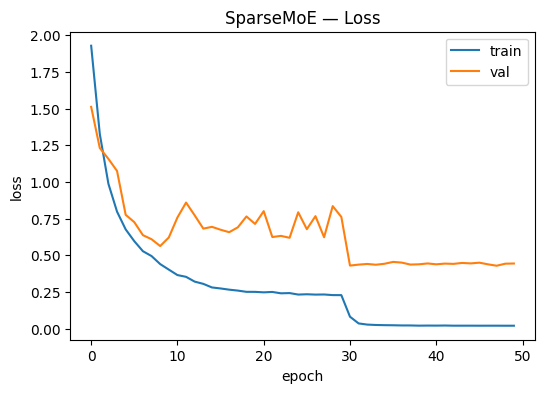

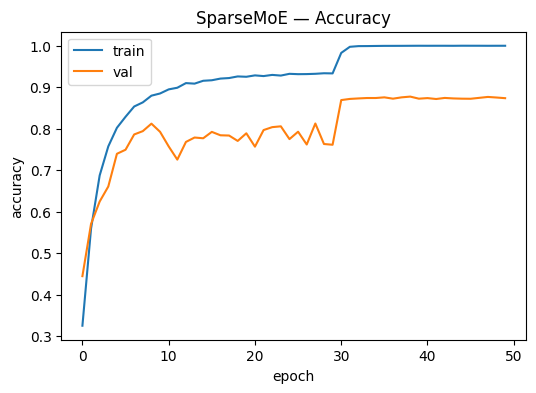

In [3]:
# Load metrics.pt and plot loss/accuracy
import os, torch, numpy as np
import matplotlib.pyplot as plt

# Must match the run config
FF_LAYER = "SparseMoE"
EPOCHS   = 50
NUM_EXPERTS = 16
SPARSEMOE_K = 2


# Mirror train_cifar10.py logic
if FF_LAYER == "Dense":
    run_tag = f"E{EPOCHS}"
elif FF_LAYER == "SparseMoE":
    run_tag = f"E{EPOCHS}-X{NUM_EXPERTS}-K{SPARSEMOE_K}"
else:
    run_tag = f"E{EPOCHS}-X{NUM_EXPERTS}"


ckpt_dir = os.path.join("/content/mixture-of-experts-project", "checkpoints", FF_LAYER, run_tag)
metrics_path = os.path.join(ckpt_dir, "metrics.pt")
assert os.path.exists(metrics_path), f"metrics.pt not found at {metrics_path}"

# load hist dict from metrics.pt
hist = torch.load(metrics_path, map_location="cpu", weights_only=False)



train_loss = np.array(hist["train_loss"])
train_acc  = np.array(hist["train_acc"])
val_loss   = np.array(hist["val_loss"])
val_acc    = np.array(hist["val_acc"])

plt.figure(figsize=(6,4))
plt.plot(train_loss, label="train")
plt.plot(val_loss,   label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title(f"{FF_LAYER} — Loss"); plt.legend(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_acc, label="train")
plt.plot(val_acc,   label="val")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title(f"{FF_LAYER} — Accuracy"); plt.legend(); plt.show()


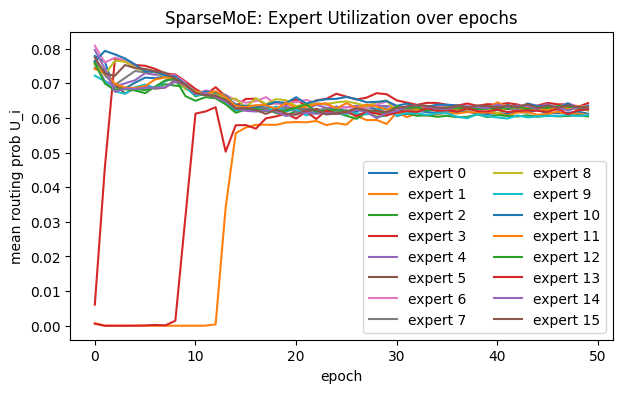

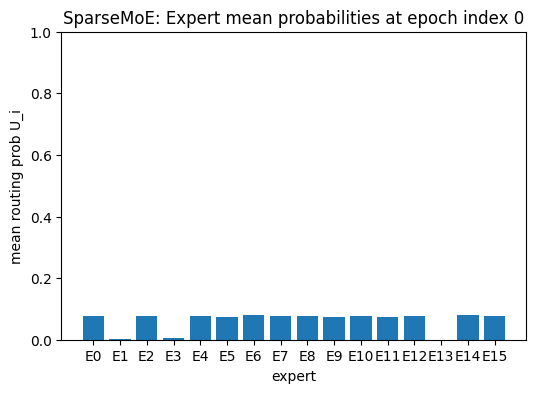

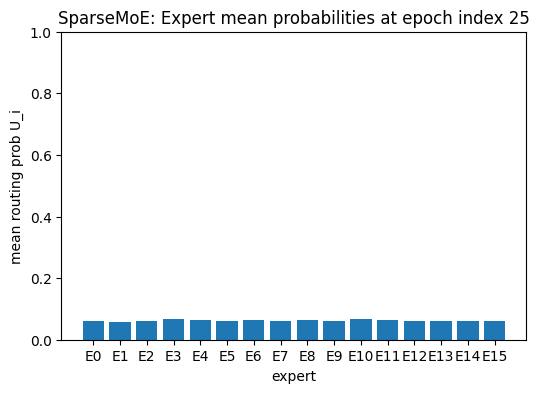

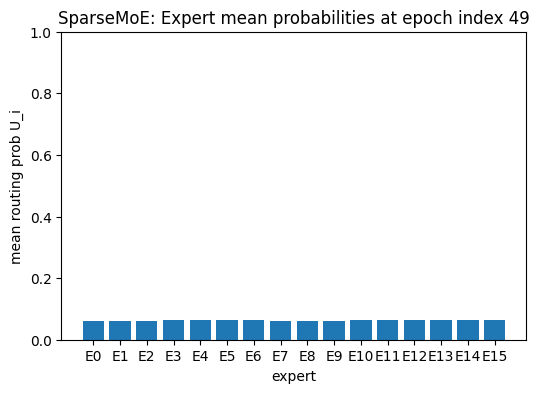

In [16]:
# Expert Utilization
from moe.utils.helpers import plot_expert_utilization
plot_expert_utilization(hist, ff_layer=FF_LAYER, epochs_to_bar=(0, 25, 49))


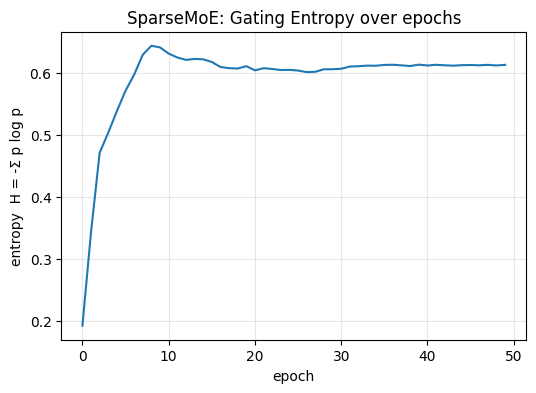

In [17]:
# Gating Entropy
from src.moe.utils.helpers import plot_gating_entropy
plot_gating_entropy(hist, ff_layer=FF_LAYER)


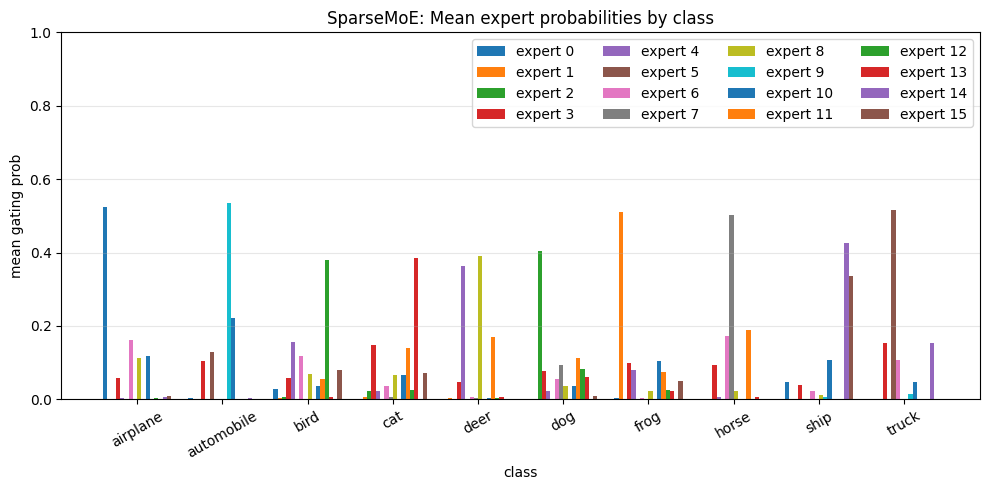

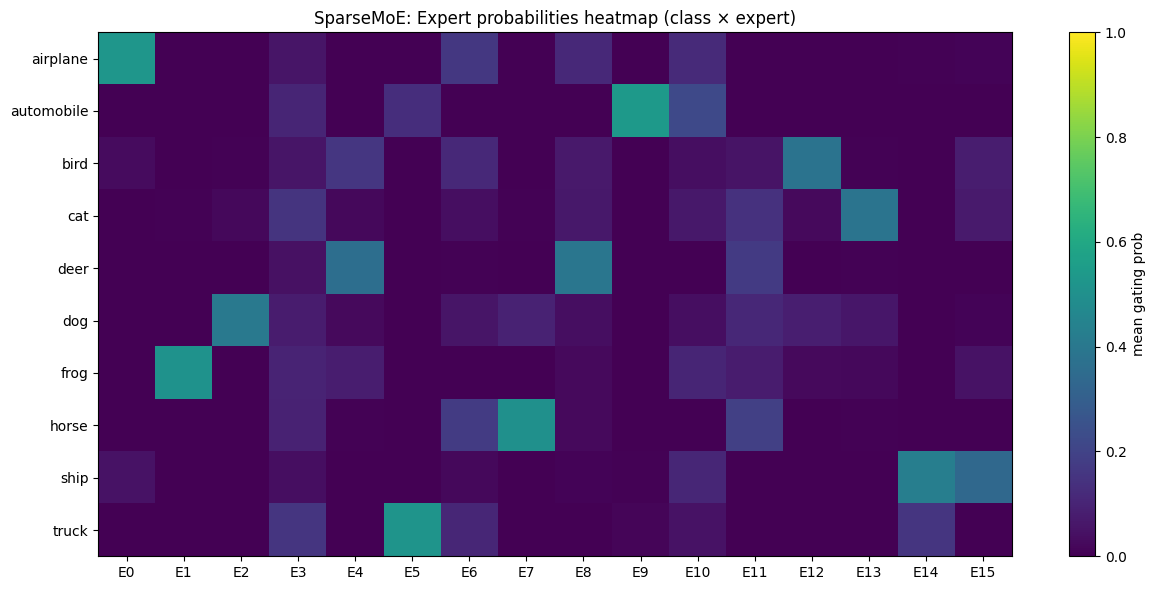

In [18]:
from src.moe.utils.helpers import plot_expert_probs_by_class, plot_expert_probs_heatmap

class_expert_mean = hist.get("class_expert_mean", None)
class_names = hist.get("class_names", None)

if class_expert_mean is None:
    print("No 'class_expert_mean' found in metrics. Make sure you ran SoftMoE and Step 1 code saved it.")
else:
    plot_expert_probs_by_class(class_expert_mean, class_names, ff_layer=FF_LAYER)
    plot_expert_probs_heatmap(class_expert_mean, class_names, ff_layer=FF_LAYER)


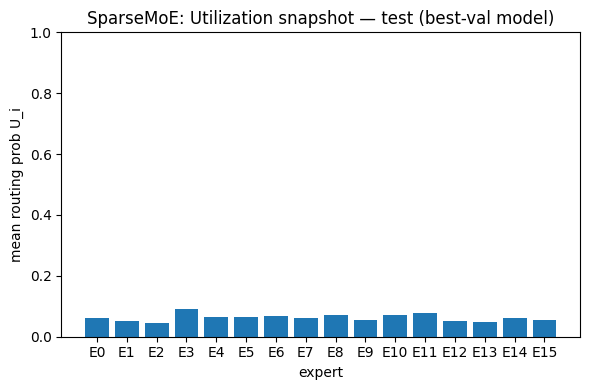

In [19]:
#gating network utilization on test set with learned model
from src.moe.utils.helpers import plot_expert_utilization_snapshot

if "util_test_snapshot" in hist:
    plot_expert_utilization_snapshot(hist["util_test_snapshot"], ff_layer=FF_LAYER)
else:
    print("No test snapshot found in metrics.pt — run the new test snapshot code first.")


#Now visualizing actual load balannce --above is probability balance



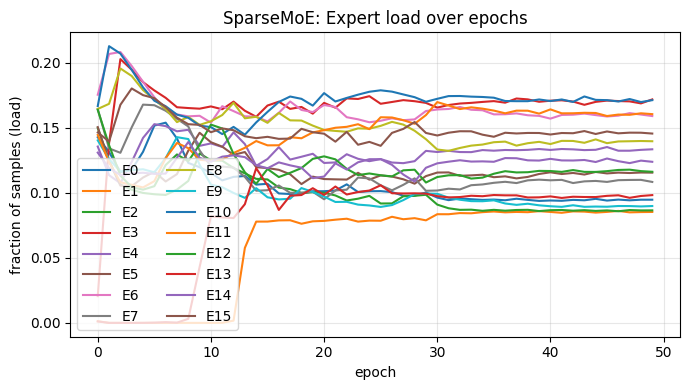

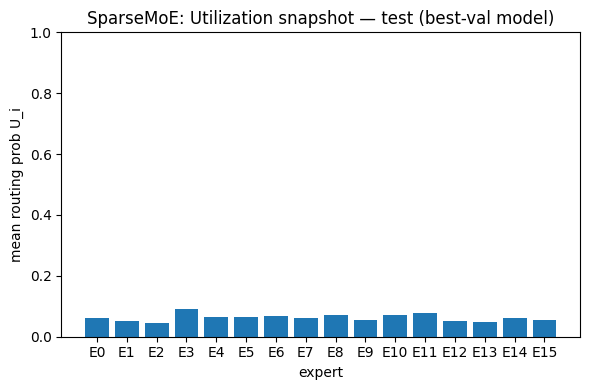

In [20]:
from moe.utils.helpers import (
    plot_expert_utilization_snapshot,
    plot_expert_load_over_epochs,
)

plot_expert_load_over_epochs(hist, ff_layer=FF_LAYER)
plot_expert_utilization_snapshot(hist["util_test_snapshot"], ff_layer=FF_LAYER)


# Now we try top 1 -- same Shazeer implementation

In [21]:
# Train via CLI so argparse is used

!python scripts/train_cifar10.py --FF_layer SparseMoE --epochs 50 --num_experts 16 --dropout_p 0.1 --temperature 1 --sparsemoe_importance_coef 0.2 --sparsemoe_load_coef 0.2 --sparsemoe_k 1


dataloaders metadata: {'mean': (0.4914, 0.4822, 0.4465), 'std': (0.247, 0.2435, 0.2616), 'num_classes': 10, 'sizes': {'train': 45000, 'val': 5000, 'test': 10000}}
Epoch 1/50: 100% 352/352 [00:15<00:00, 22.52it/s]
Epoch 001/50 | train_loss=2.1009 train_acc=39.38% | val_loss=1.5569 val_acc=45.78%
Saved checkpoint: SparseMoE val_acc=45.78%
Epoch 2/50: 100% 352/352 [00:15<00:00, 23.30it/s]
Epoch 002/50 | train_loss=1.4524 train_acc=61.97% | val_loss=1.0834 val_acc=61.10%
Saved checkpoint: SparseMoE val_acc=61.10%
Epoch 3/50: 100% 352/352 [00:14<00:00, 23.65it/s]
Epoch 003/50 | train_loss=1.1418 train_acc=71.73% | val_loss=0.8914 val_acc=68.72%
Saved checkpoint: SparseMoE val_acc=68.72%
Epoch 4/50: 100% 352/352 [00:14<00:00, 23.81it/s]
Epoch 004/50 | train_loss=0.9507 train_acc=77.78% | val_loss=0.7912 val_acc=74.02%
Saved checkpoint: SparseMoE val_acc=74.02%
Epoch 5/50: 100% 352/352 [00:14<00:00, 23.79it/s]
Epoch 005/50 | train_loss=0.8499 train_acc=80.87% | val_loss=1.2277 val_acc=64.12%


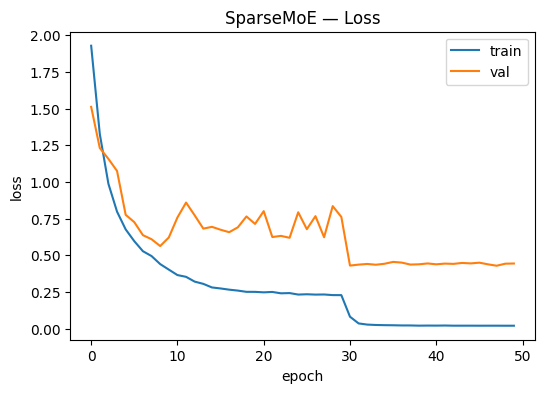

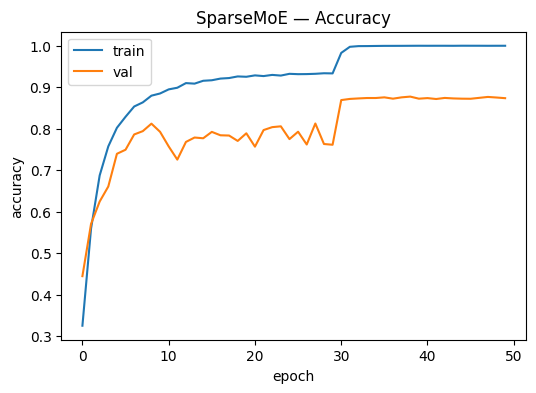

In [22]:
# Load metrics.pt and plot loss/accuracy
import os, torch, numpy as np
import matplotlib.pyplot as plt

# Must match the run config
FF_LAYER = "SparseMoE"
EPOCHS   = 50
NUM_EXPERTS = 16
SPARSEMOE_K = 2


# Mirror train_cifar10.py logic
if FF_LAYER == "Dense":
    run_tag = f"E{EPOCHS}"
elif FF_LAYER == "SparseMoE":
    run_tag = f"E{EPOCHS}-X{NUM_EXPERTS}-K{SPARSEMOE_K}"
else:
    run_tag = f"E{EPOCHS}-X{NUM_EXPERTS}"


ckpt_dir = os.path.join("/content/mixture-of-experts-project", "checkpoints", FF_LAYER, run_tag)
metrics_path = os.path.join(ckpt_dir, "metrics.pt")
assert os.path.exists(metrics_path), f"metrics.pt not found at {metrics_path}"

# load hist dict from metrics.pt
hist = torch.load(metrics_path, map_location="cpu", weights_only=False)



train_loss = np.array(hist["train_loss"])
train_acc  = np.array(hist["train_acc"])
val_loss   = np.array(hist["val_loss"])
val_acc    = np.array(hist["val_acc"])

plt.figure(figsize=(6,4))
plt.plot(train_loss, label="train")
plt.plot(val_loss,   label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title(f"{FF_LAYER} — Loss"); plt.legend(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_acc, label="train")
plt.plot(val_acc,   label="val")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title(f"{FF_LAYER} — Accuracy"); plt.legend(); plt.show()


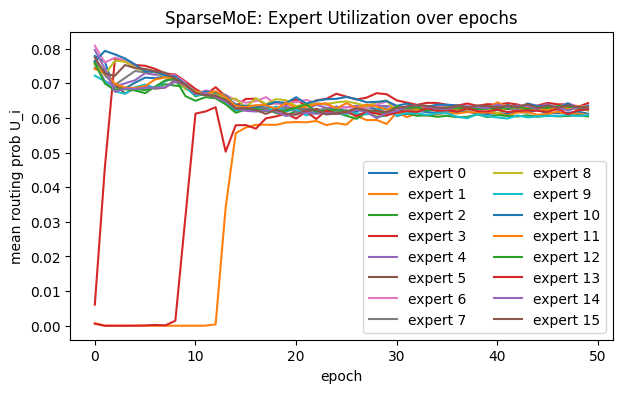

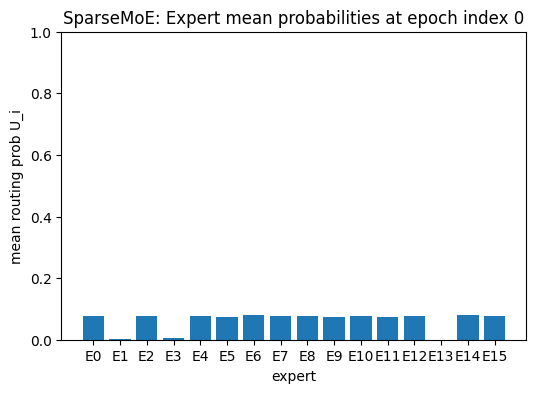

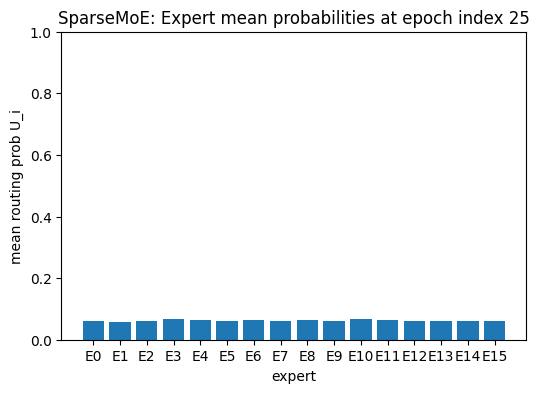

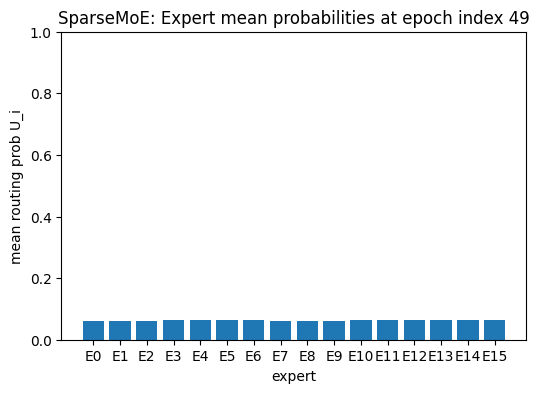

In [23]:
# Expert Utilization
from moe.utils.helpers import plot_expert_utilization
plot_expert_utilization(hist, ff_layer=FF_LAYER, epochs_to_bar=(0, 25, 49))


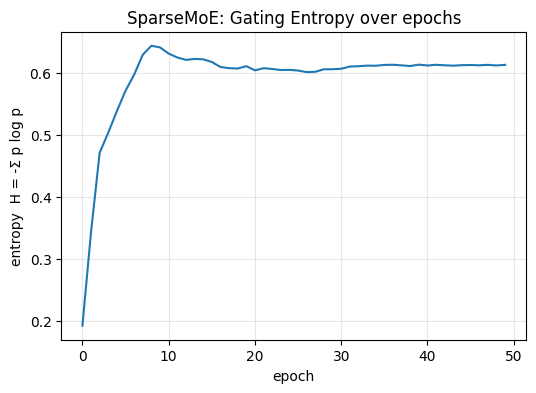

In [24]:
# Gating Entropy
from src.moe.utils.helpers import plot_gating_entropy
plot_gating_entropy(hist, ff_layer=FF_LAYER)


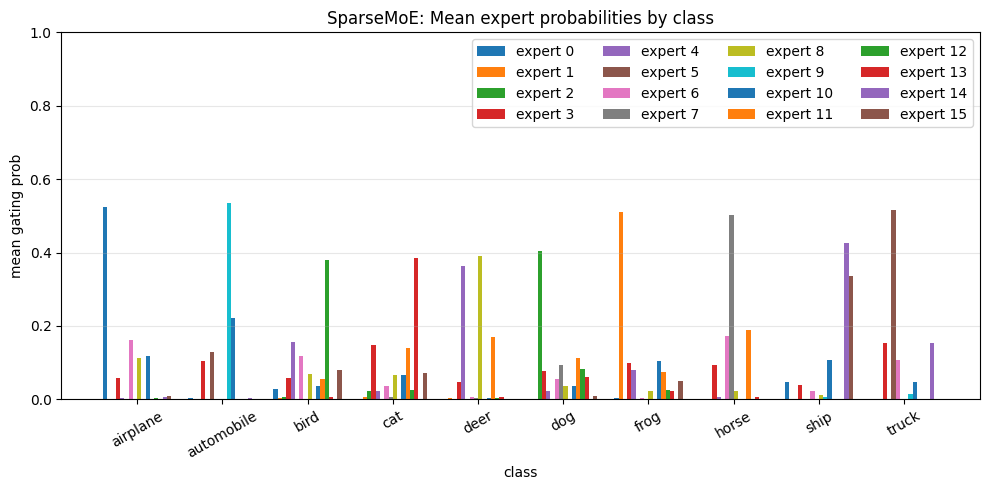

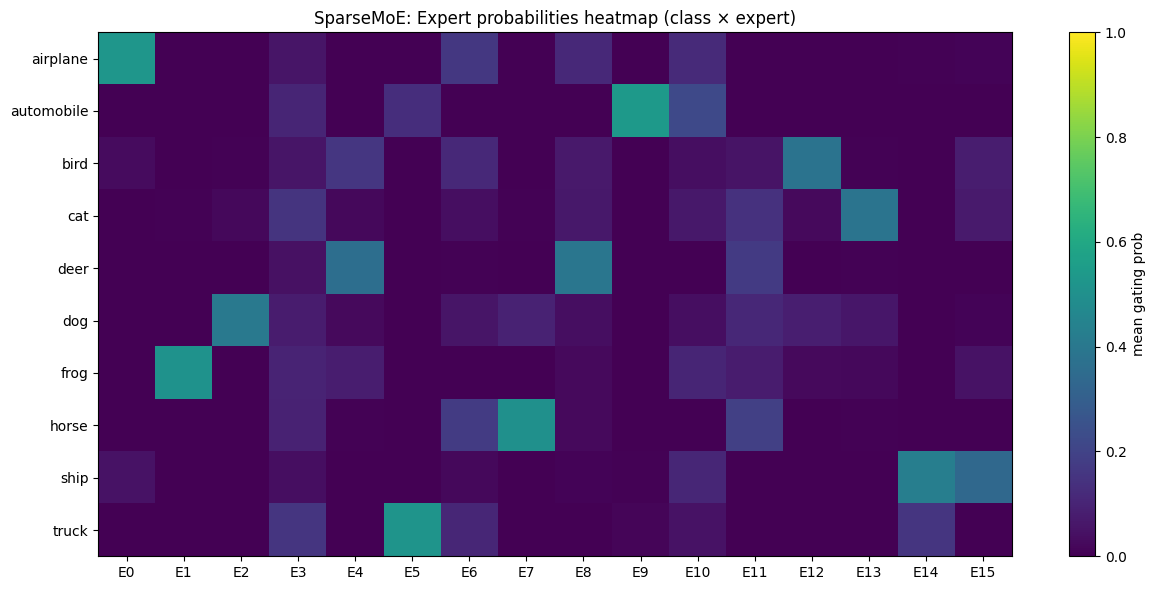

In [25]:
from src.moe.utils.helpers import plot_expert_probs_by_class, plot_expert_probs_heatmap

class_expert_mean = hist.get("class_expert_mean", None)
class_names = hist.get("class_names", None)

if class_expert_mean is None:
    print("No 'class_expert_mean' found in metrics. Make sure you ran SoftMoE and Step 1 code saved it.")
else:
    plot_expert_probs_by_class(class_expert_mean, class_names, ff_layer=FF_LAYER)
    plot_expert_probs_heatmap(class_expert_mean, class_names, ff_layer=FF_LAYER)


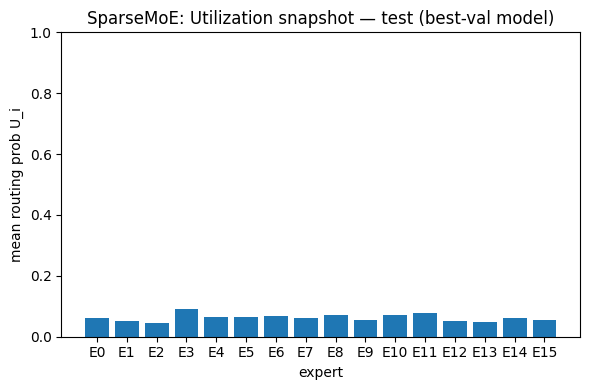

In [26]:
#gating network utilization on test set with learned model
from src.moe.utils.helpers import plot_expert_utilization_snapshot

if "util_test_snapshot" in hist:
    plot_expert_utilization_snapshot(hist["util_test_snapshot"], ff_layer=FF_LAYER)
else:
    print("No test snapshot found in metrics.pt — run the new test snapshot code first.")


#Now visualizing actual load balannce --above is probability balance

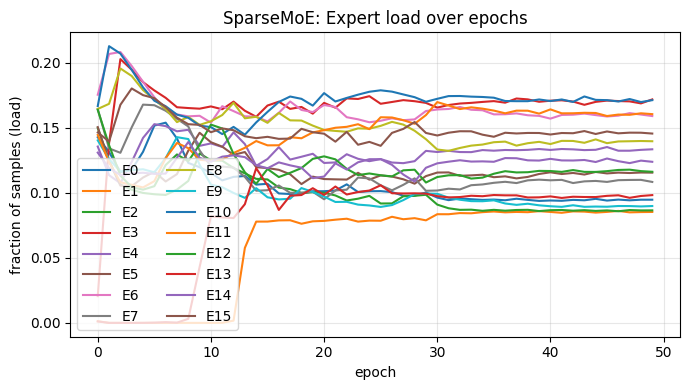

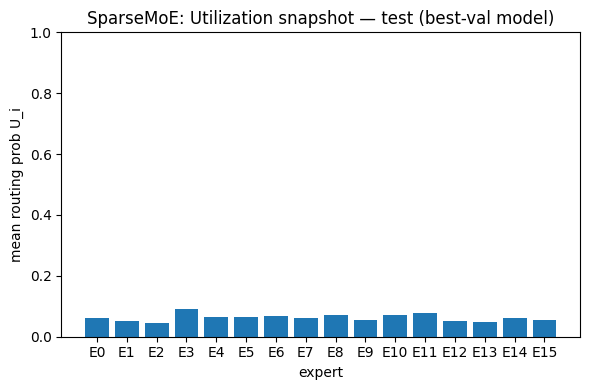

In [27]:
from moe.utils.helpers import (
    plot_expert_utilization_snapshot,
    plot_expert_load_over_epochs,
)

plot_expert_load_over_epochs(hist, ff_layer=FF_LAYER)
plot_expert_utilization_snapshot(hist["util_test_snapshot"], ff_layer=FF_LAYER)
